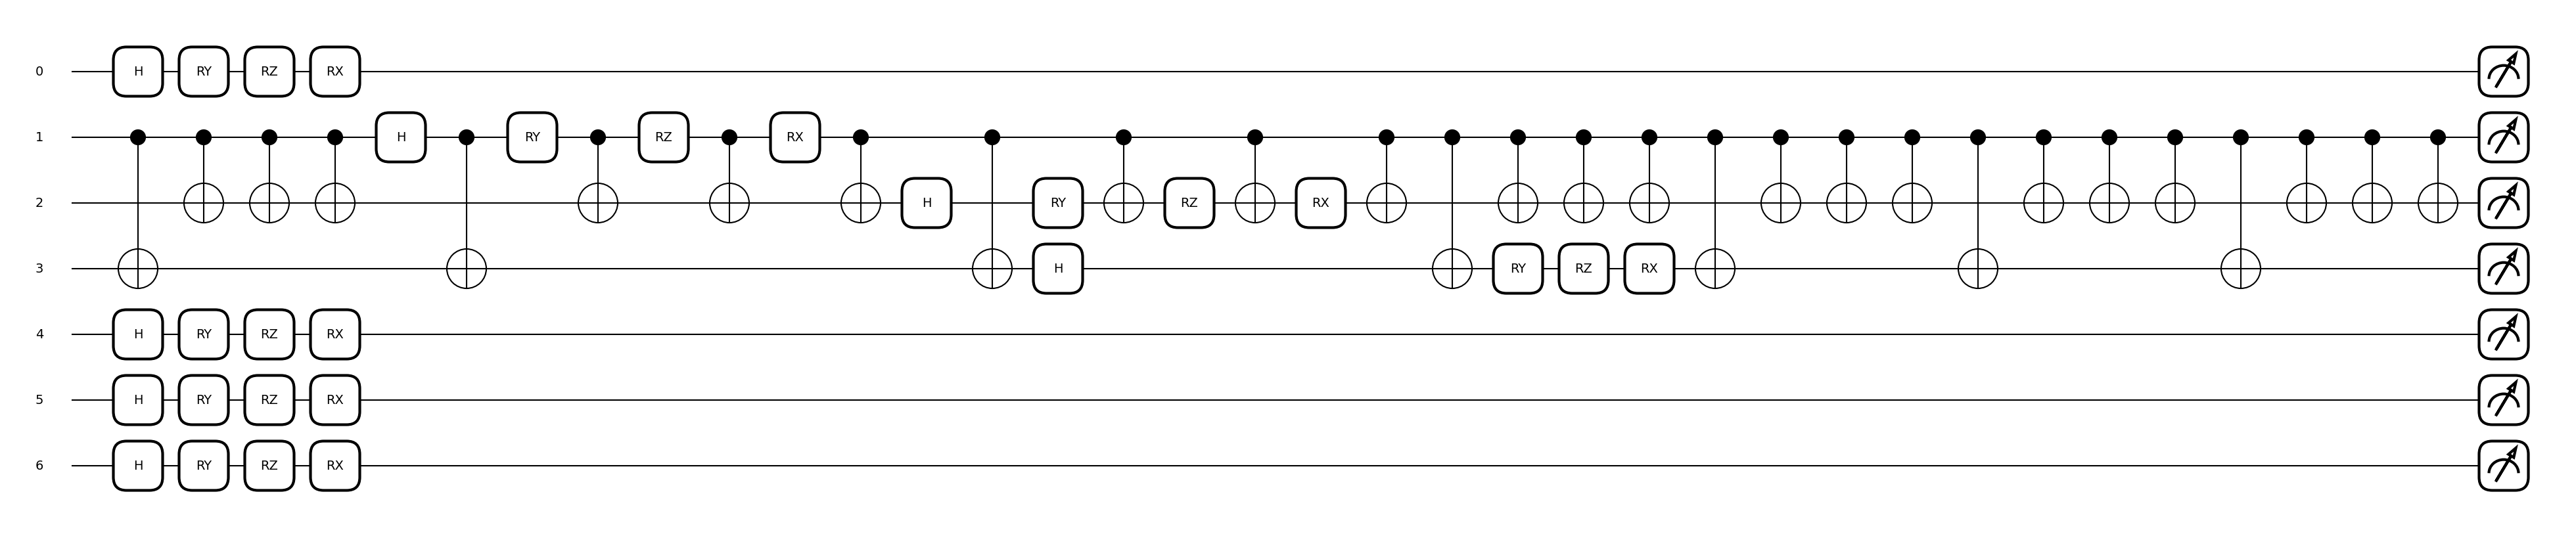

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv(r'C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\DATASET\2D electronic properties2.csv',encoding='ISO-8859–1')       
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]

# Splitting the dataset into training and test set.  
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.07, random_state=2)  

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

# Quantum setup
n_qubits = 7
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)

# Sample test data

X_test_scaled = scaler.transform(x_test)

# Compute the test kernel matrix (train-test kernel)
K_test = np.zeros((len(X_test_scaled), len(X_train_scaled)))
for i in range(len(X_test_scaled)):
    for j in range(len(X_train_scaled)):
        K_test[i, j] = quantum_kernel(X_test_scaled[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred = svr.predict(K_test)
print("Predicted values:", y_pred)

Predicted values: [0.5631926  0.16849728 1.28669886 2.88136267 4.0681331  4.65601221
 0.49750498 3.51651306 0.92257654 1.86762748 1.04270195 1.91595334
 2.50194566 2.21425491 0.71255222 0.29466652 3.17605244 3.71047567
 0.62552683 2.10171441 1.14945073 2.23833872 0.20767686 1.76382576
 0.90528744 1.9246312  1.97139555 1.78824226 0.94178488 0.43879839
 0.21071802 3.11731188 0.38153555 0.56857565 2.84396581 2.0666686
 1.67585975 2.88151104 0.61943551 0.6135497  0.96998288 5.49230009
 0.24464988 1.94071795 1.42846535 3.40564859 0.73635714 0.87211834
 1.59053511 0.15660694 0.52313854 3.85013941 2.20129683 3.87949383
 1.4638409  2.55153774 0.67709905 2.73225333 1.45055519 0.92568139
 0.60937748 1.43004943 0.11279918 3.72203631 2.10113572 0.44852795
 0.33281309 1.47170721 3.68907677 3.06094843 1.71035622 2.06042804
 0.74674629 1.17761261 1.24961073 3.54813106 2.35389754 4.5631668
 0.09862066 0.66691473 0.57107466 4.40676412 1.31438786 1.1659651
 4.35114776 3.27464789 1.10656261 1.25930944 2.

train r^2: 0.998901386159988
train MAE 0.04029439176166768
train RMSE: 0.04701562388275143


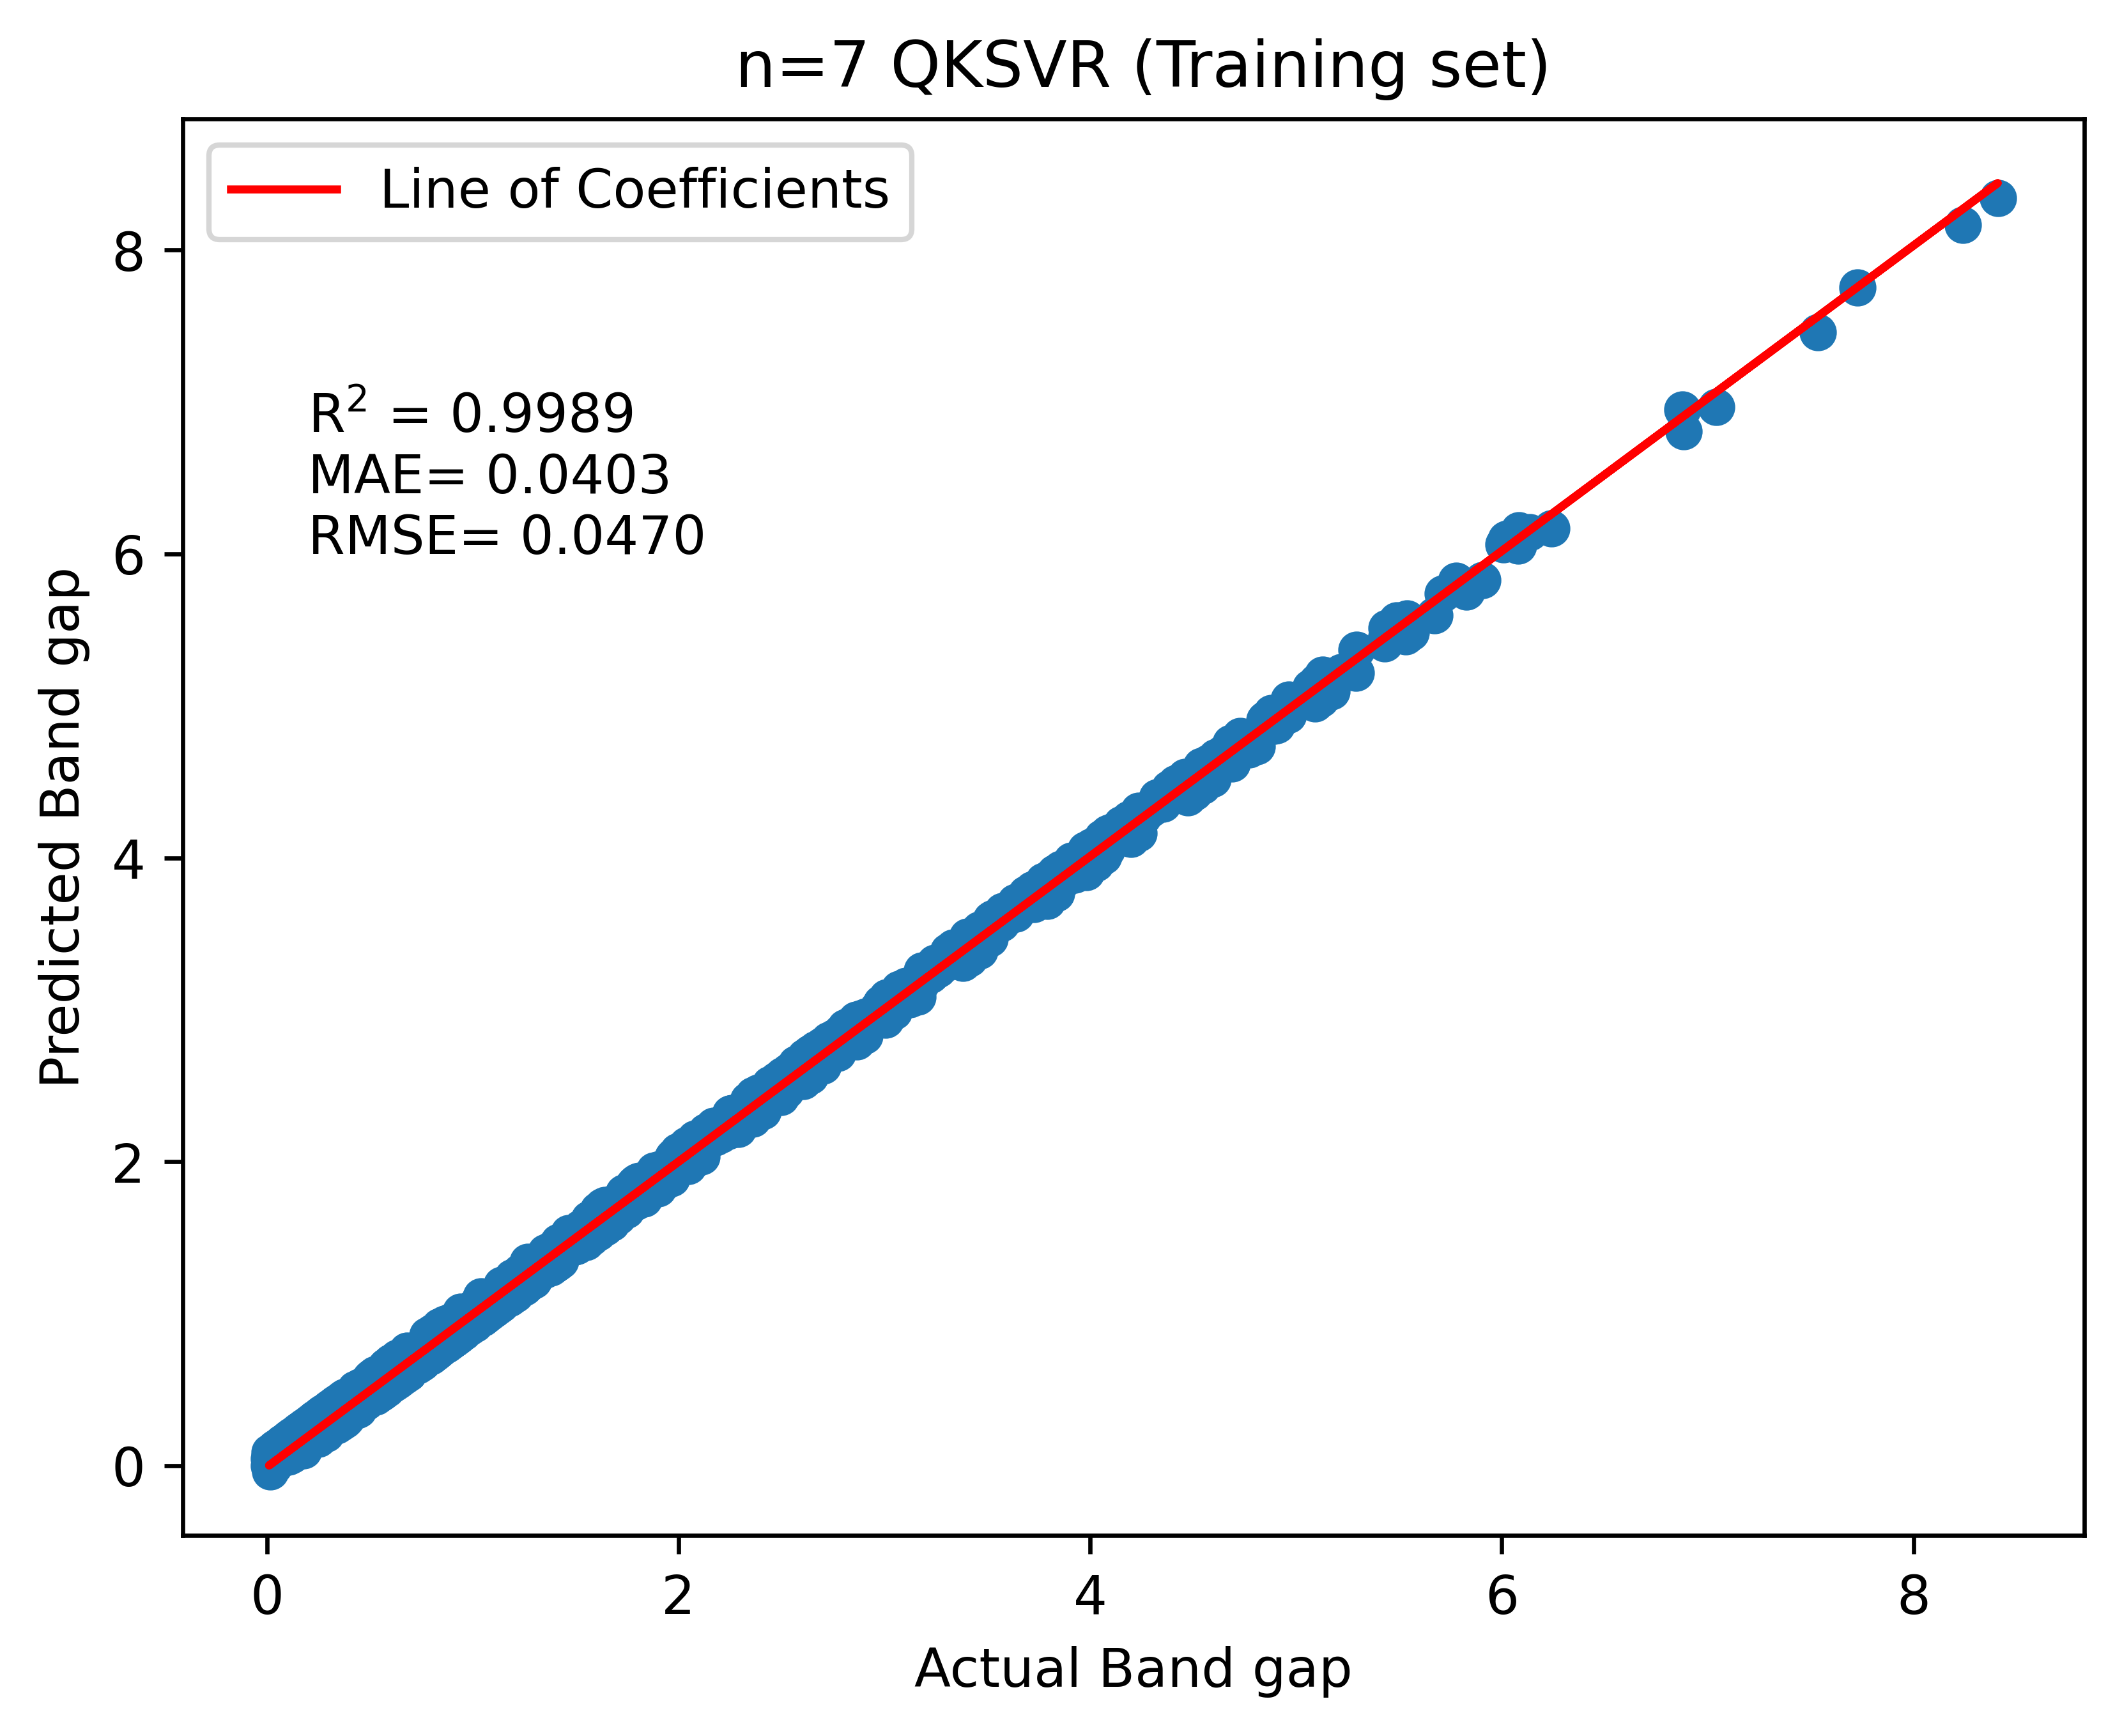

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd

from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.4f}".format(r2_score(y_train,y_predtrain)), (0.2, 6.80))
plt.annotate("MAE= {:.4f}".format(mean_absolute_error(y_train,y_predtrain)), (0.2, 6.4))
plt.annotate("RMSE= {:.4f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (0.2, 6.0))
plt.title(" n=7 QKSVR (Training set)")#title
plt.legend()

Model evaluation - Test Set:
r^2: 0.998192144401371
RSE 0.0028892579495013657
RAE 0.04287241582001773
RMSE: 0.053751818104147565


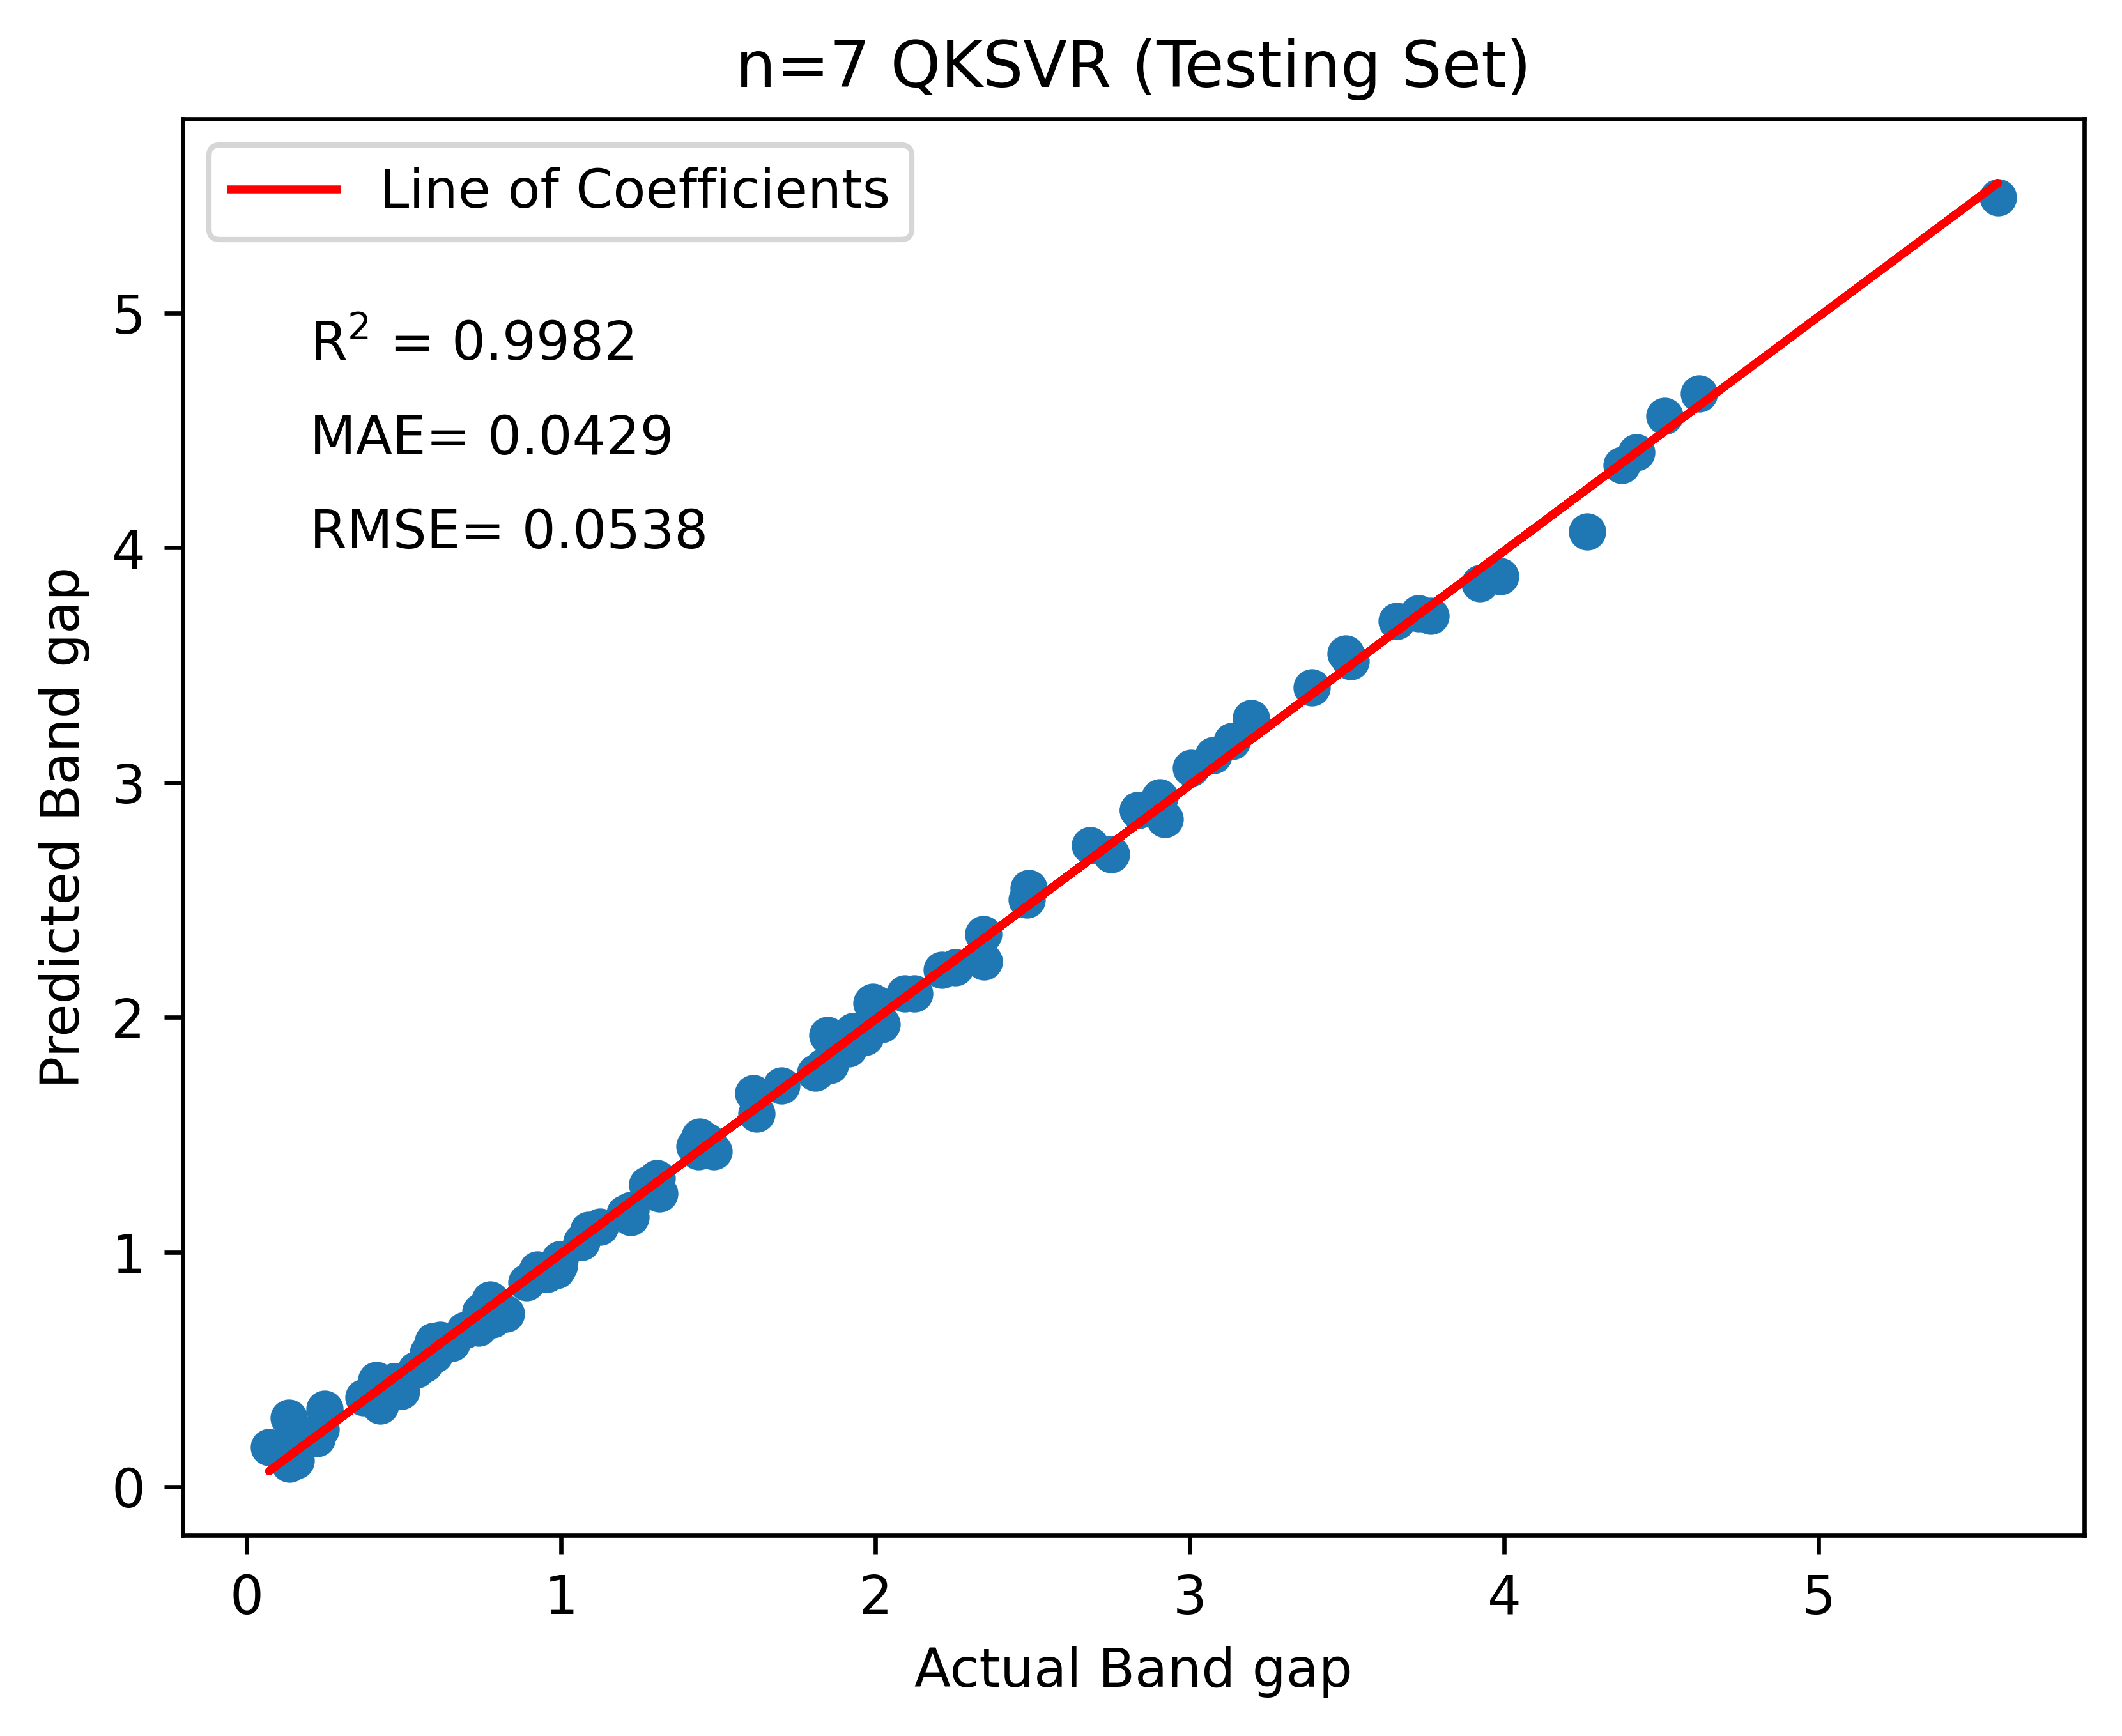

In [5]:
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd

from sklearn import ensemble
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
print("Model evaluation - Test Set:")
print('r^2:',r2_score(y_test, y_pred))
print('RSE', mean_squared_error(y_test, y_pred))
print('RAE', mean_absolute_error(y_test, y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y_test, y_pred)
coefficients = np.polyfit(y_test, y_pred, 1)
line = np.polyval(coefficients, y_test)
plt.plot(y_test, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_test, line, color='r',)
plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R$^2$ = {:.4f}".format(r2_score(y_test, y_pred)), (0.2, 4.80))
plt.annotate("RMSE= {:.4f}".format(np.sqrt(mean_squared_error(y_test, y_pred))), (0.2, 4.0))
plt.annotate("MAE= {:.4f}".format(mean_absolute_error(y_test, y_pred)), (0.2, 4.4))
plt.title("n=7 QKSVR (Testing Set)")#title
plt.legend()

In [42]:
# ============================================================
# TRAINING-RESIDUAL BOOTSTRAP PREDICTION INTERVAL
# 95% PERCENTILE INTERVAL
#
# Metrics:
#   1. CR / PICP
#   2. MPIW
#   3. MWP
#   4. MC = MWP / CR
#
# NO MODEL TRAINING
# ============================================================

import numpy as np


# ============================================================
# 1. INPUT DATA FROM ALREADY-TRAINED MODEL
# ============================================================

# Actual training targets
y_train_arr = np.asarray(y_train, dtype=float)

# Predictions on training data from the already-trained model
y_predtrain_arr = np.asarray(y_predtrain, dtype=float)

# Actual test targets
y_test_arr = np.asarray(y_test, dtype=float)

# Predictions on test data from the already-trained model
y_pred_test_arr = np.asarray(y_pred, dtype=float)


# ============================================================
# 2. CHECK DATA
# ============================================================

if len(y_train_arr) != len(y_predtrain_arr):
    raise ValueError(
        "y_train and y_predtrain must have the same length."
    )

if len(y_test_arr) != len(y_pred_test_arr):
    raise ValueError(
        "y_test and y_pred must have the same length."
    )

if len(y_train_arr) < 2:
    raise ValueError(
        "At least two training samples are required."
    )


# ============================================================
# 3. TRAINING RESIDUALS
# ============================================================

train_residuals = (
    y_train_arr - y_predtrain_arr
)


# ============================================================
# 4. BOOTSTRAP SETTINGS
# ============================================================

B = 1000

confidence = 0.95

lower_percentile = 2.5
upper_percentile = 97.5

random_seed = 42

rng = np.random.default_rng(random_seed)


# ============================================================
# 5. NUMBER OF TEST SAMPLES
# ============================================================

n_train = len(y_train_arr)
n_test = len(y_test_arr)


# ============================================================
# 6. GENERATE BOOTSTRAP PREDICTIONS
# ============================================================

bootstrap_predictions = np.empty(
    (B, n_test),
    dtype=float
)


for b in range(B):

    # Resample TRAINING residuals with replacement
    residual_sample = rng.choice(
        train_residuals,
        size=n_test,
        replace=True
    )

    # Add bootstrap residuals to existing test predictions
    bootstrap_predictions[b, :] = (
        y_pred_test_arr +
        residual_sample
    )


# ============================================================
# 7. 95% BOOTSTRAP PERCENTILE PREDICTION INTERVAL
# ============================================================

Low = np.percentile(
    bootstrap_predictions,
    lower_percentile,
    axis=0
)

Up = np.percentile(
    bootstrap_predictions,
    upper_percentile,
    axis=0
)


# ============================================================
# 8. PREDICTION INTERVAL WIDTH
# ============================================================

interval_width = Up - Low


# ============================================================
# 9. CR / PICP
# ============================================================

inside = (
    (y_test_arr >= Low) &
    (y_test_arr <= Up)
)

c = np.sum(inside)

CR = c / n_test

CR_percent = CR * 100


# ============================================================
# 10. MPIW
# ============================================================

MPIW = np.mean(
    interval_width
)


# ============================================================
# 11. MWP
# ============================================================

# Exclude zero / near-zero observed values
valid = (
    np.abs(y_test_arr) > 1e-12
)

if np.sum(valid) > 0:

    MWP = np.mean(
        interval_width[valid]
        / np.abs(y_test_arr[valid])
    ) * 100

else:

    MWP = np.nan


# ============================================================
# 12. MC
# ============================================================
# MC = Mean Width Percentage / Coverage Rate

if CR > 0:

    MC = MWP / CR

else:

    MC = np.nan


# ============================================================
# 13. BOOTSTRAP SUMMARY
# ============================================================

bootstrap_mean = np.mean(
    bootstrap_predictions,
    axis=0
)

bootstrap_std = np.std(
    bootstrap_predictions,
    axis=0,
    ddof=1
)


# ============================================================
# 14. RESULTS
# ============================================================

print("\n======================================================")
print(" TRAINING-RESIDUAL BOOTSTRAP PREDICTION INTERVAL")
print("======================================================")

print(f"Training samples                  = {n_train}")
print(f"Test samples                      = {n_test}")
print(f"Bootstrap samples                 = {B}")
print(f"Confidence level                  = {confidence * 100:.1f}%")
print(f"Lower percentile                  = {lower_percentile:.1f}%")
print(f"Upper percentile                  = {upper_percentile:.1f}%")

print("\n------------------------------------------------------")
print("CR / PICP")
print("------------------------------------------------------")

print(f"Points inside interval            = {c}")
print(f"Total test points                 = {n_test}")
print(f"CR / PICP                          = {CR:.4f}")
print(f"CR / PICP (%)                      = {CR_percent:.2f}%")

print("\n------------------------------------------------------")
print("MPIW")
print("------------------------------------------------------")

print(
    f"Mean Prediction Interval Width    = {MPIW:.6f}"
)

print("\n------------------------------------------------------")
print("MWP")
print("------------------------------------------------------")

print(
    f"Mean Width Percentage              = {MWP:.2f}%"
)

print("\n------------------------------------------------------")
print("MC")
print("------------------------------------------------------")

print(
    f"MC = MWP / CR                      = {MC:.4f}"
)

print("\n======================================================")


 TRAINING-RESIDUAL BOOTSTRAP PREDICTION INTERVAL
Training samples                  = 1303
Test samples                      = 99
Bootstrap samples                 = 1000
Confidence level                  = 95.0%
Lower percentile                  = 2.5%
Upper percentile                  = 97.5%

------------------------------------------------------
CR / PICP
------------------------------------------------------
Points inside interval            = 86
Total test points                 = 99
CR / PICP                          = 0.8687
CR / PICP (%)                      = 86.87%

------------------------------------------------------
MPIW
------------------------------------------------------
Mean Prediction Interval Width    = 0.150104

------------------------------------------------------
MWP
------------------------------------------------------
Mean Width Percentage              = 21.15%

------------------------------------------------------
MC
--------------------------------------

<Figure size 3840x2880 with 0 Axes>

<Figure size 3840x2880 with 0 Axes>

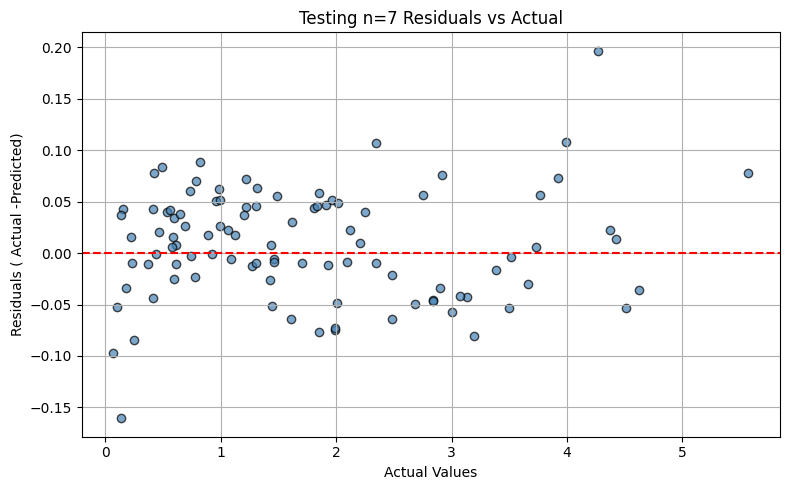

<Figure size 3840x2880 with 0 Axes>

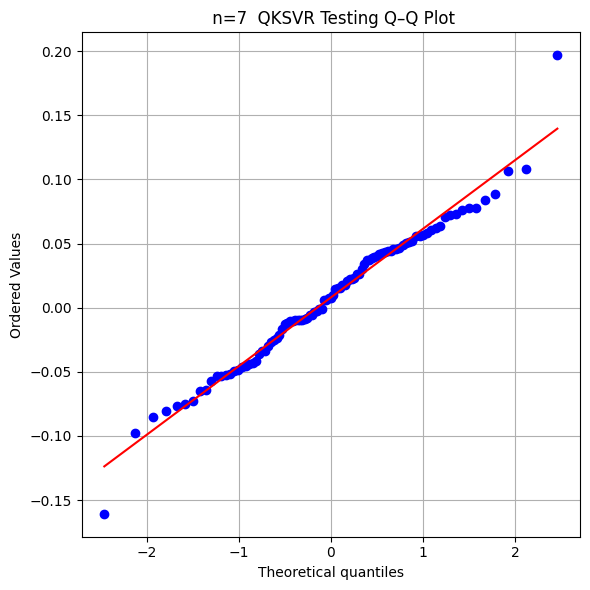

<Figure size 3840x2880 with 0 Axes>

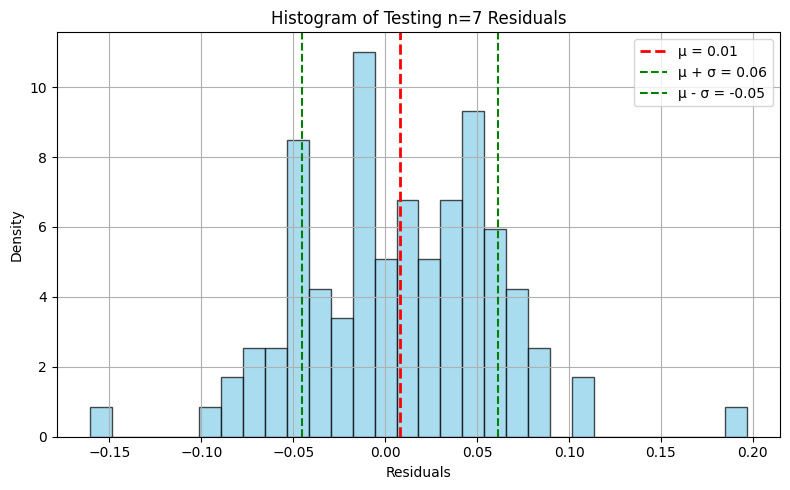

<Figure size 3840x2880 with 0 Axes>

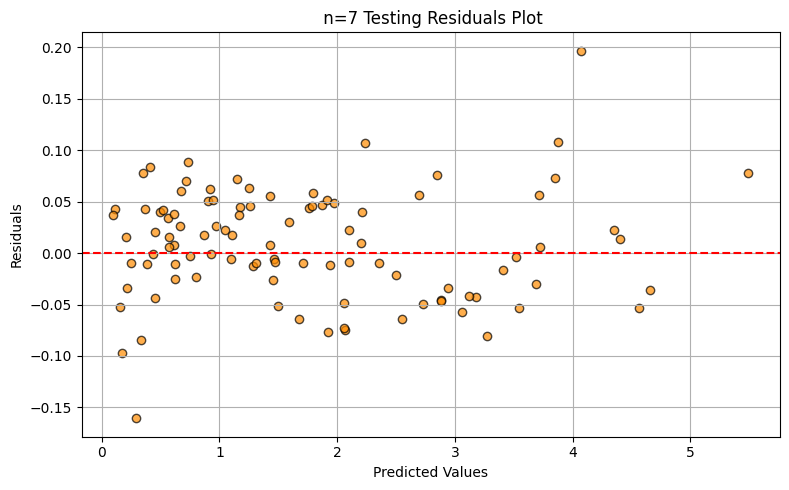

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assume you already have:
# Y1 = actual values
# predtestextX1 = predicted values from model M1-P1

residuals_test =  y_test-y_pred
mu = np.mean(residuals_test)
sigma = np.std(residuals_test)
plt.figure(dpi=600)
# 1. Residuals vs Actual
plt.figure(dpi=600)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals_test, alpha=0.7, color='steelblue', edgecolors='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Actual Values")
plt.ylabel("Residuals ( Actual -Predicted)")
plt.title("Testing n=7 Residuals vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Q–Q Plot of Residuals
plt.figure(dpi=600)
plt.figure(figsize=(6, 6))
stats.probplot(residuals_test, dist="norm", plot=plt)
plt.title(" n=7  QKSVR Testing Q–Q Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Histogram of Residuals with μ and σ
plt.figure(dpi=600)
plt.figure(figsize=(8, 5))
plt.hist(residuals_test, bins=30, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'μ = {mu:.2f}')
plt.axvline(mu + sigma, color='green', linestyle='--', linewidth=1.5, label=f'μ + σ = {mu + sigma:.2f}')
plt.axvline(mu - sigma, color='green', linestyle='--', linewidth=1.5, label=f'μ - σ = {mu - sigma:.2f}')
plt.title('Histogram of Testing n=7 Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Residuals vs Predicted
plt.figure(dpi=600)
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals_test, alpha=0.7, color='darkorange', edgecolors='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(" n=7 Testing Residuals Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
import numpy as np
import scipy.stats as stats

# Basic Stats
mean_restest= np.mean(residuals_test)
std_restest= np.std(residuals_test)
var_restest = np.var(residuals_test)
min_restest = np.min(residuals_test)
max_restest= np.max(residuals_test)
median_restest= np.median(residuals_test)

# Skewness and Kurtosis
skew_restest= stats.skew(residuals_test)
kurt_restest= stats.kurtosis(residuals_test)  # Fisher (normal = 0)

# Normality Test
shapiro_test= stats.shapiro(residuals_test)



# Print Results
print(f"Mean test: {mean_restest:.4f}")
print(f"Standard Deviation  test: {std_restest:.4f}")
print(f"Variance test: {var_restest:.4f}")
print(f"Min  test: {min_restest:.4f}")
print(f"Max  test: {max_restest:.4f}")
print(f"Median test: {median_restest:.4f}")
print(f"Skewness  test: {skew_restest:.4f}")
print(f"Kurtosis  test: {kurt_restest:.4f}")
print(f"Shapiro-Wilk Test Statistic  test: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")



Mean test: 0.0080
Standard Deviation  test: 0.0532
Variance test: 0.0028
Min  test: -0.1607
Max  test: 0.1969
Median test: 0.0076
Skewness  test: 0.0438
Kurtosis  test: 0.9922
Shapiro-Wilk Test Statistic  test: 0.9822, p-value: 0.2006


In [15]:
df2=pd.read_csv('C:/Users/NIT/Desktop/PAPER FINALIZED WORK BAND 2D DT-25-02-2025/other qubit variation using optimized hyp/study-fm-pro/uncetainity and valida/external dataset/50 dataset repeat.csv',encoding='ISO-8859–1') 
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df2['Band gap ']

# defining target
x2=df2[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [4.22218037 0.20212667 0.75146878 0.91042587 1.80092074 1.17579184
 4.07355874 0.5629622  3.12848717 1.68280717 3.08130473 0.44746423
 2.9437204  0.64880107 3.16000649 0.15180717 0.70358255 3.69516222
 1.60871667 0.76692537 3.60092508 0.87911607 1.51710656 0.30636233
 1.92502425 1.52593103 0.6358012  0.94702875 0.58292992 1.1021043
 3.56925552 2.17655226 1.28088354 4.03215336 0.58147591 0.81830834
 2.53194312 2.04531774 1.02984533 0.18207403 1.12190713 1.3399562
 0.65456107 1.39352095 3.68335323 1.23047057 0.61115291 2.21629699
 3.09531643 1.05952043]


In [18]:
import numpy as np
from scipy.stats import shapiro

errors_50 = np.asarray(y2) - np.asarray(y_pred2)

W, p_value = shapiro(errors_50)

print("Shapiro-Wilk W-dataset-50 =", W)
print("p-value-dataset-50 =", p_value)

Shapiro-Wilk W-dataset-50 = 0.9870465775325904
p-value-dataset-50 = 0.8547397295471173


In [ ]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Band gap")
plt.ylabel("Predicted Band gap")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=7 QSVR (EV-datset-50)")#title
plt.legend()

In [19]:
df3=pd.read_csv('C:/Users/NIT/Desktop/PAPER FINALIZED WORK BAND 2D DT-25-02-2025/other qubit variation using optimized hyp/study-fm-pro/uncetainity and valida/external dataset/100 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [1.89844376 1.88212216 2.05179351 1.53865171 0.80351069 2.53351082
 2.33613149 1.40625867 4.51607108 1.81730463 4.06069031 1.84880472
 1.19848743 1.60033492 4.49339558 1.10197772 1.54249223 1.0254417
 0.53775983 0.47053875 1.50703474 1.35946982 2.27792687 0.60495162
 0.39613448 1.58544424 3.18528018 2.05151552 1.43145756 2.61813137
 0.42756835 0.82753412 0.2340962  2.1394984  1.16228807 0.65091607
 2.81265494 4.23611353 1.07022589 0.81324628 1.4429221  1.13634085
 4.10023823 0.53950351 1.82023631 0.36811119 5.26300197 2.08182428
 2.0622351  1.5172606  1.09593895 2.19629425 0.75108158 2.3580809
 0.43933679 1.25889427 1.01827807 0.47653877 4.72488047 1.68875571
 0.40930035 0.99439123 0.6209607  0.8165284  4.5281868  0.35870978
 0.9085185  2.0307375  2.02399262 1.63697555 0.38984433 3.09919057
 1.16401971 4.76814143 3.8004633  4.88997169 2.41108757 2.80854027
 4.96650365 0.36891579 0.28548799 0.23263243 2.01085857 1.04349809
 3.31383267 0.7507647  5.46507319 1.3876989  1

In [28]:
import numpy as np
from scipy.stats import shapiro

errors_100 = np.asarray(y3) - np.asarray(y_pred3)

W, p_value = shapiro(errors_100)

print("Shapiro-Wilk W-dataset-100 =", W)
print("p-value-dataset-100 =", p_value)

Shapiro-Wilk W-dataset-100 = 0.921899793376547
p-value-dataset-100 = 1.7776440429465106e-05


Model evaluation - Test Set:
r^2: 0.988614738908487
MAE 0.11211423452997052
RMSE: 0.14295821748745036


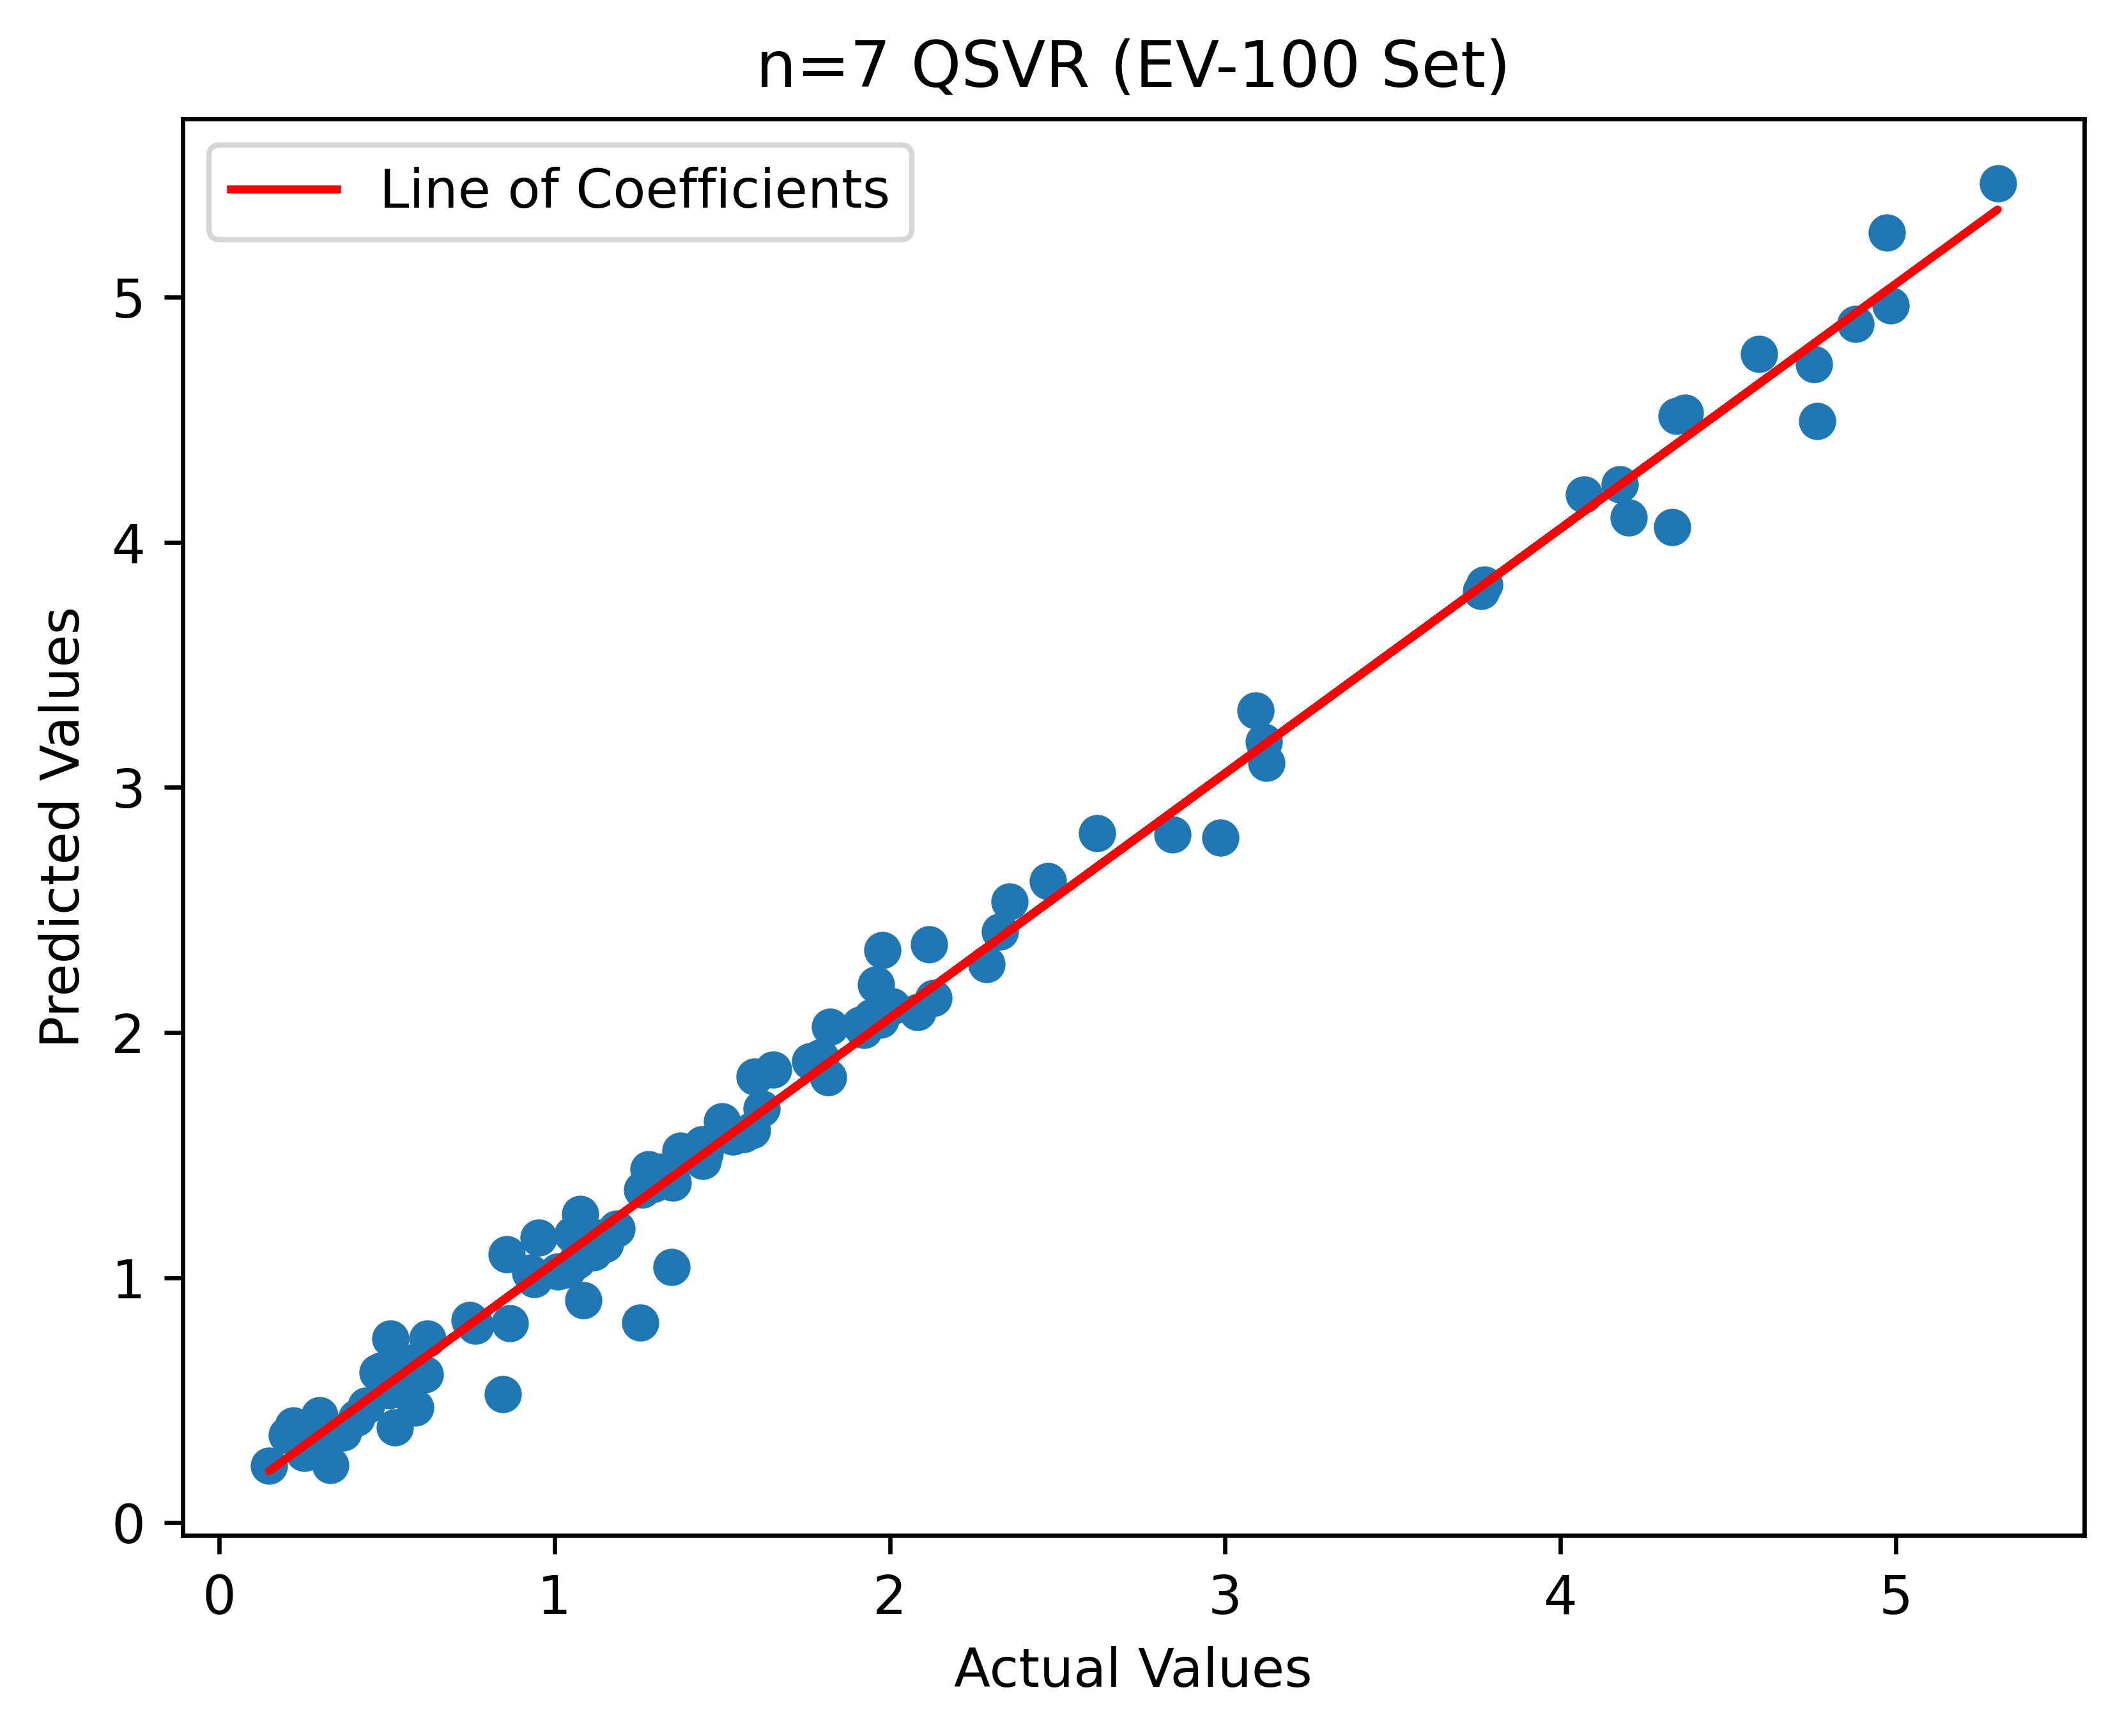

In [20]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=7 QSVR (EV-100 Set)")#title
plt.legend()

In [21]:

df4=pd.read_csv('C:/Users/NIT/Desktop/PAPER FINALIZED WORK BAND 2D DT-25-02-2025/other qubit variation using optimized hyp/study-fm-pro/uncetainity and valida/external dataset/200 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [2.27901046 0.16426949 2.94892988 0.48219483 2.34697737 1.37309392
 0.80601296 0.30466012 1.09433753 1.70532824 0.44814752 0.59192077
 4.35547598 1.61098763 1.58784601 0.4422075  0.94009358 0.58538595
 1.45890896 1.23091835 1.40943853 2.82742125 2.33552541 1.44706008
 0.7853996  3.42490273 3.20507286 4.67522582 0.85784962 1.54652291
 1.22555919 2.0573819  4.18299725 1.11843787 0.39527186 0.22301833
 0.74017433 1.80886989 0.34996095 1.39703828 0.50558253 1.64214067
 5.27242382 4.93694286 3.75246343 1.2297362  1.41233035 4.13057174
 3.54787581 0.77826871 3.92118018 0.6999401  0.51310985 3.79593353
 0.95949472 3.41390662 0.93493279 1.72656371 0.61307256 1.47138932
 0.33410195 0.2447221  0.17509951 0.52558368 4.51922883 1.12830343
 3.69408344 0.75225026 1.78417317 0.7076747  2.46573621 2.32369183
 4.03770925 3.63246261 3.55851426 1.32414664 1.25346496 0.98490266
 1.38654918 1.19406747 2.90199175 0.12197231 1.47692912 2.40270813
 2.3416683  1.05342058 4.48461752 2.00077772

In [29]:
import numpy as np
from scipy.stats import shapiro

errors_200 = np.asarray(y4) - np.asarray(y_pred4)

W, p_value = shapiro(errors_200)

print("Shapiro-Wilk W-dataset-200 =", W)
print("p-value-dataset-200 =", p_value)

Shapiro-Wilk W-dataset-200 = 0.9901803249337419
p-value-dataset-200 = 0.18983030922443955


Model evaluation - Test Set:
r^2: 0.9880896456405762
MAE 0.12223218069040186
RMSE: 0.1495921063880914


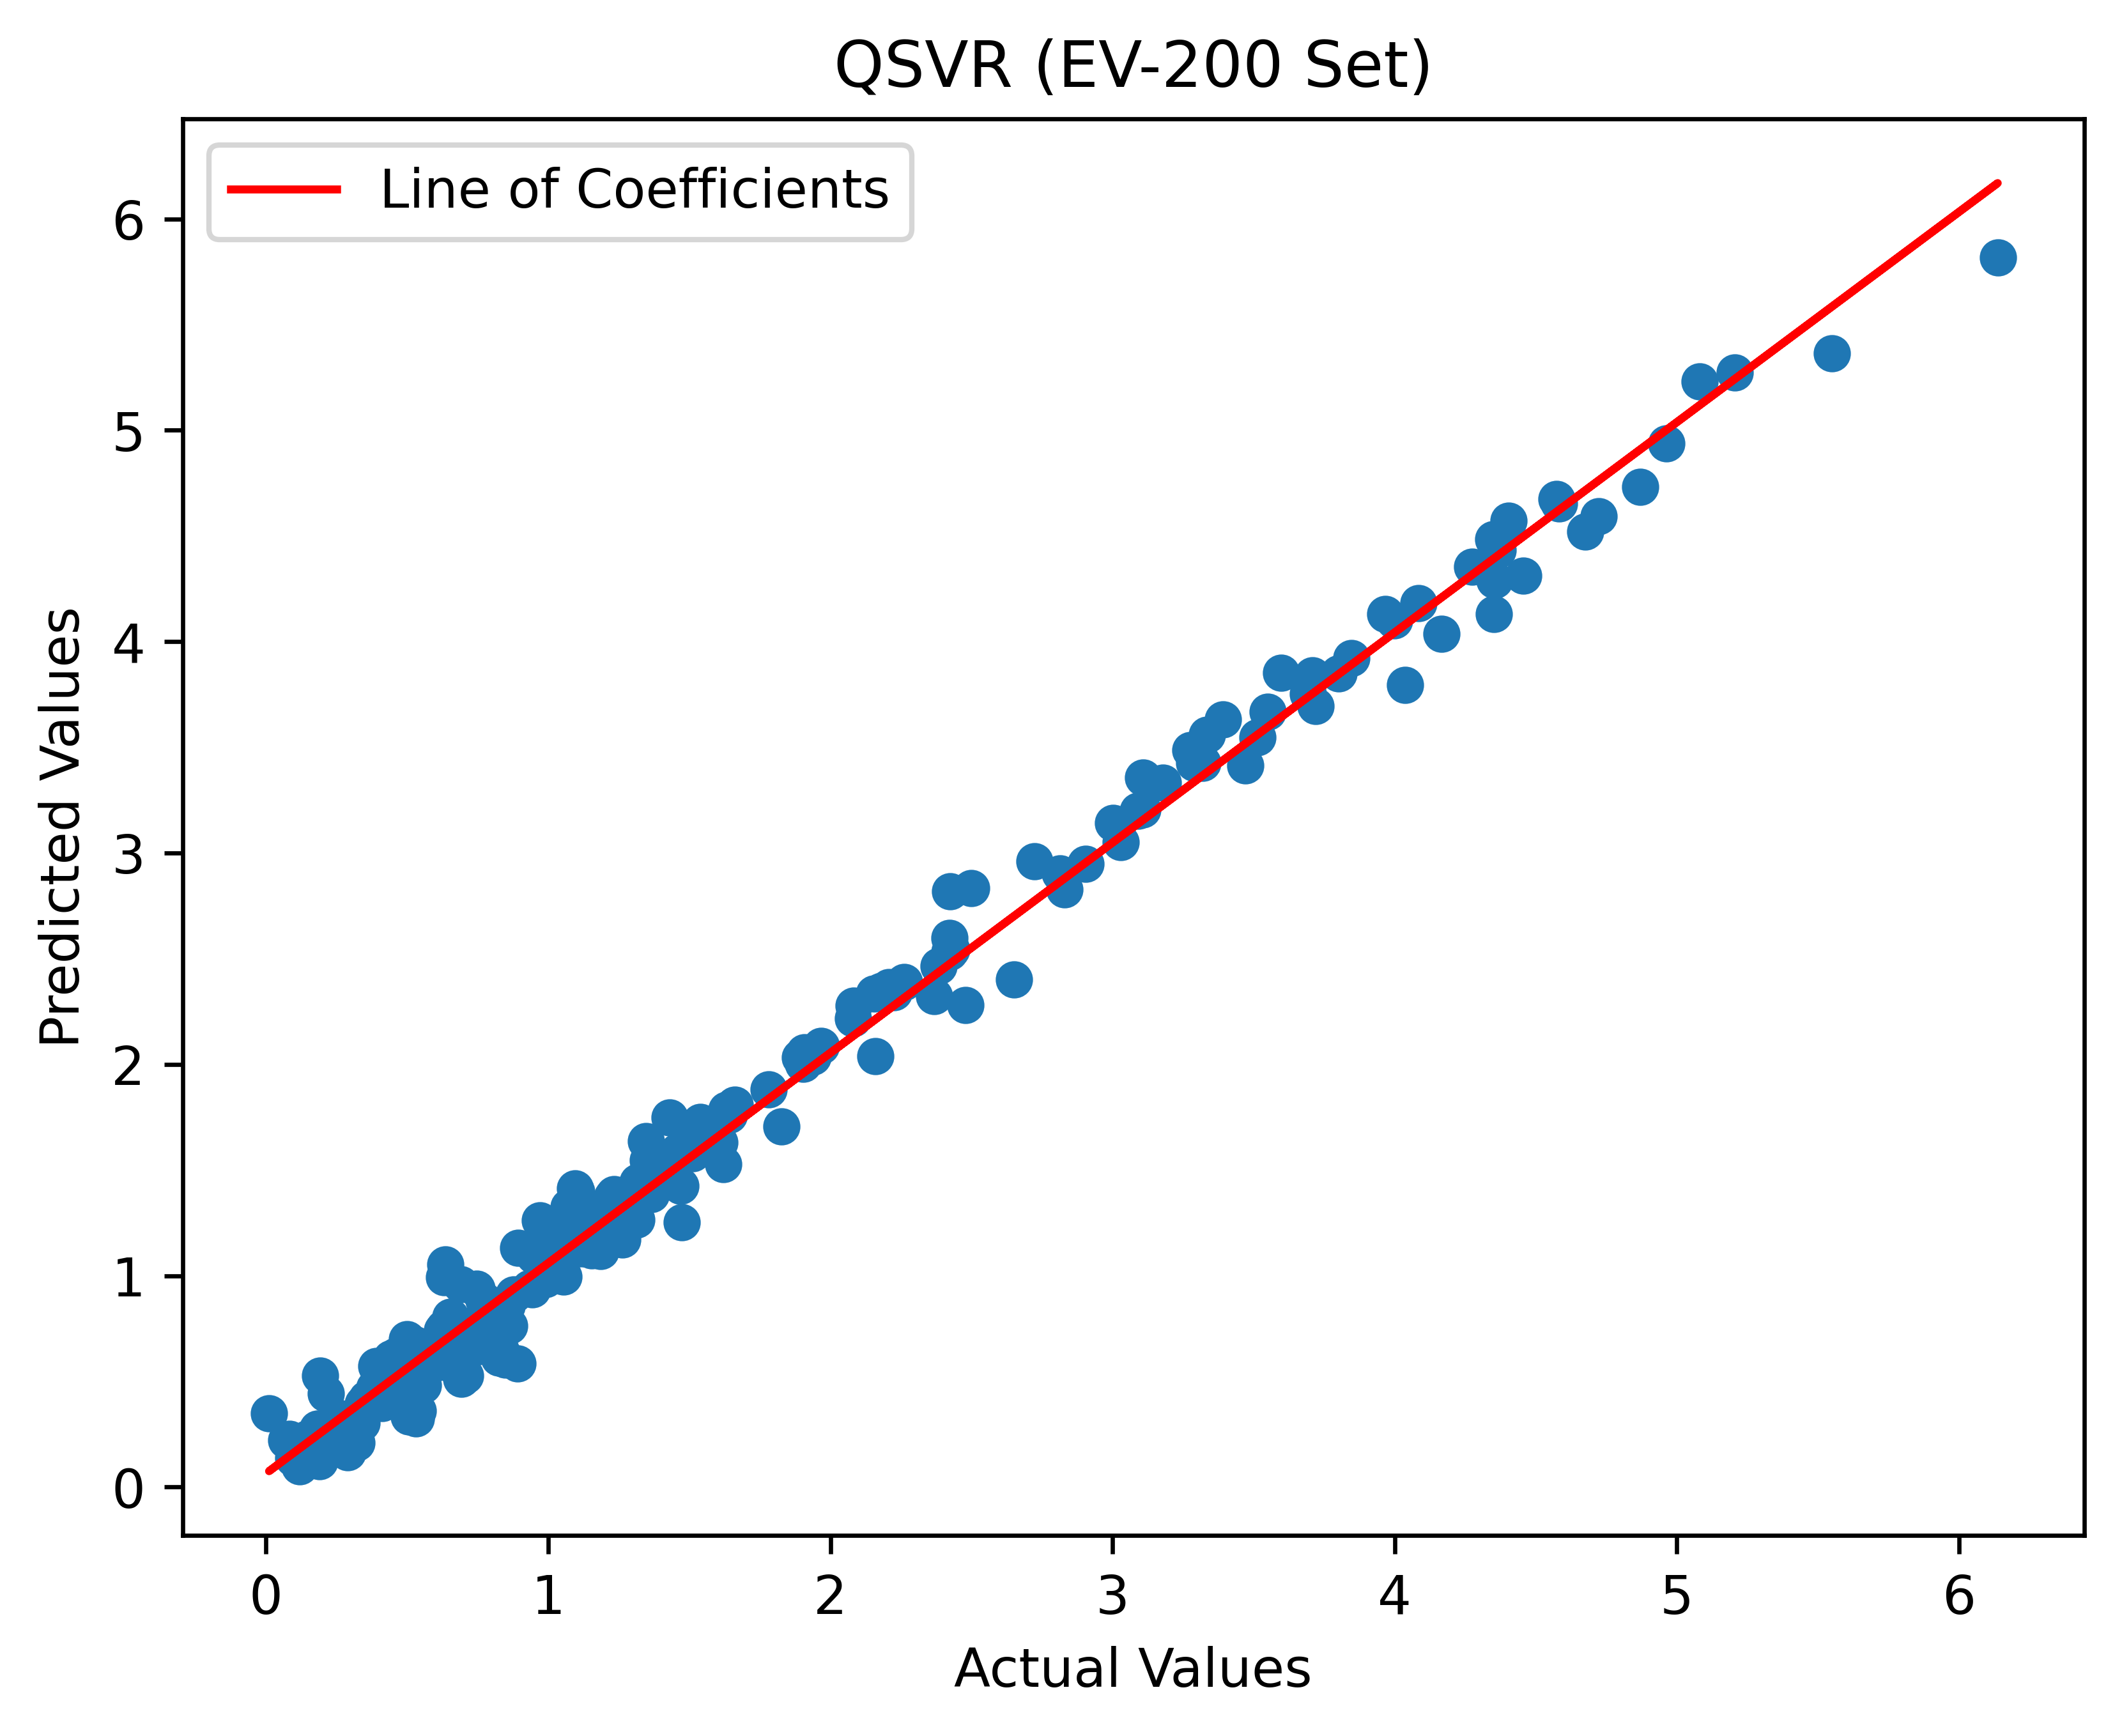

In [22]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("QSVR (EV-200 Set)")#title
plt.legend()

In [23]:
df5=pd.read_csv('C:/Users/NIT/Desktop/PAPER FINALIZED WORK BAND 2D DT-25-02-2025/other qubit variation using optimized hyp/study-fm-pro/uncetainity and valida/external dataset/400 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [ 4.50600234  0.18040781  1.30651287  0.97570501  1.24206488  0.31161103
  1.52625798  1.62106788  0.32606407  0.83982464  0.38121084  0.38562932
  0.602397    0.68928863  3.8558987   4.17308325  1.72326429  0.76340498
  3.87312376  0.11574518  2.06687102  1.79602201  1.22756831  1.63749039
  1.39061913  1.33705424  2.8012895   0.67183512  0.95896121  1.01974691
  0.96203063  2.36666209  0.58004635  1.06435298  0.87267863  1.05601369
  1.41591317  5.72596568  0.5106183   0.37617839  2.86974387  1.24898914
  1.36744734  4.34816396  1.7672284   2.32575864  0.57006609  2.02819353
  3.82999581  3.8083695   0.796686    3.00517612  1.36143363  0.64807033
  0.24999978  1.83339275  4.56406598  1.0486456   0.54736684  1.24137208
  0.44237136  0.23835975  2.62718153  1.19103298  0.86512084  0.93158444
  1.14552094  1.47599759  2.21715683  3.46021662  0.44061755  2.1423349
  0.67774163  0.13601487  0.35449951  3.77720955  1.74510052  1.5288977
  1.74799783  2.54269042  0.6397323

In [30]:
import numpy as np
from scipy.stats import shapiro

errors_400 = np.asarray(y5) - np.asarray(y_pred5)

W, p_value = shapiro(errors_400)

print("Shapiro-Wilk W-dataset-400 =", W)
print("p-value-dataset-400 =", p_value)

Shapiro-Wilk W-dataset-400 = 0.9453235713475787
p-value-dataset-400 = 5.5203849747427644e-11


Model evaluation - Test Set:
r^2: 0.9873220152142659
MAE 0.11994530054990063
RMSE: 0.152334094732149


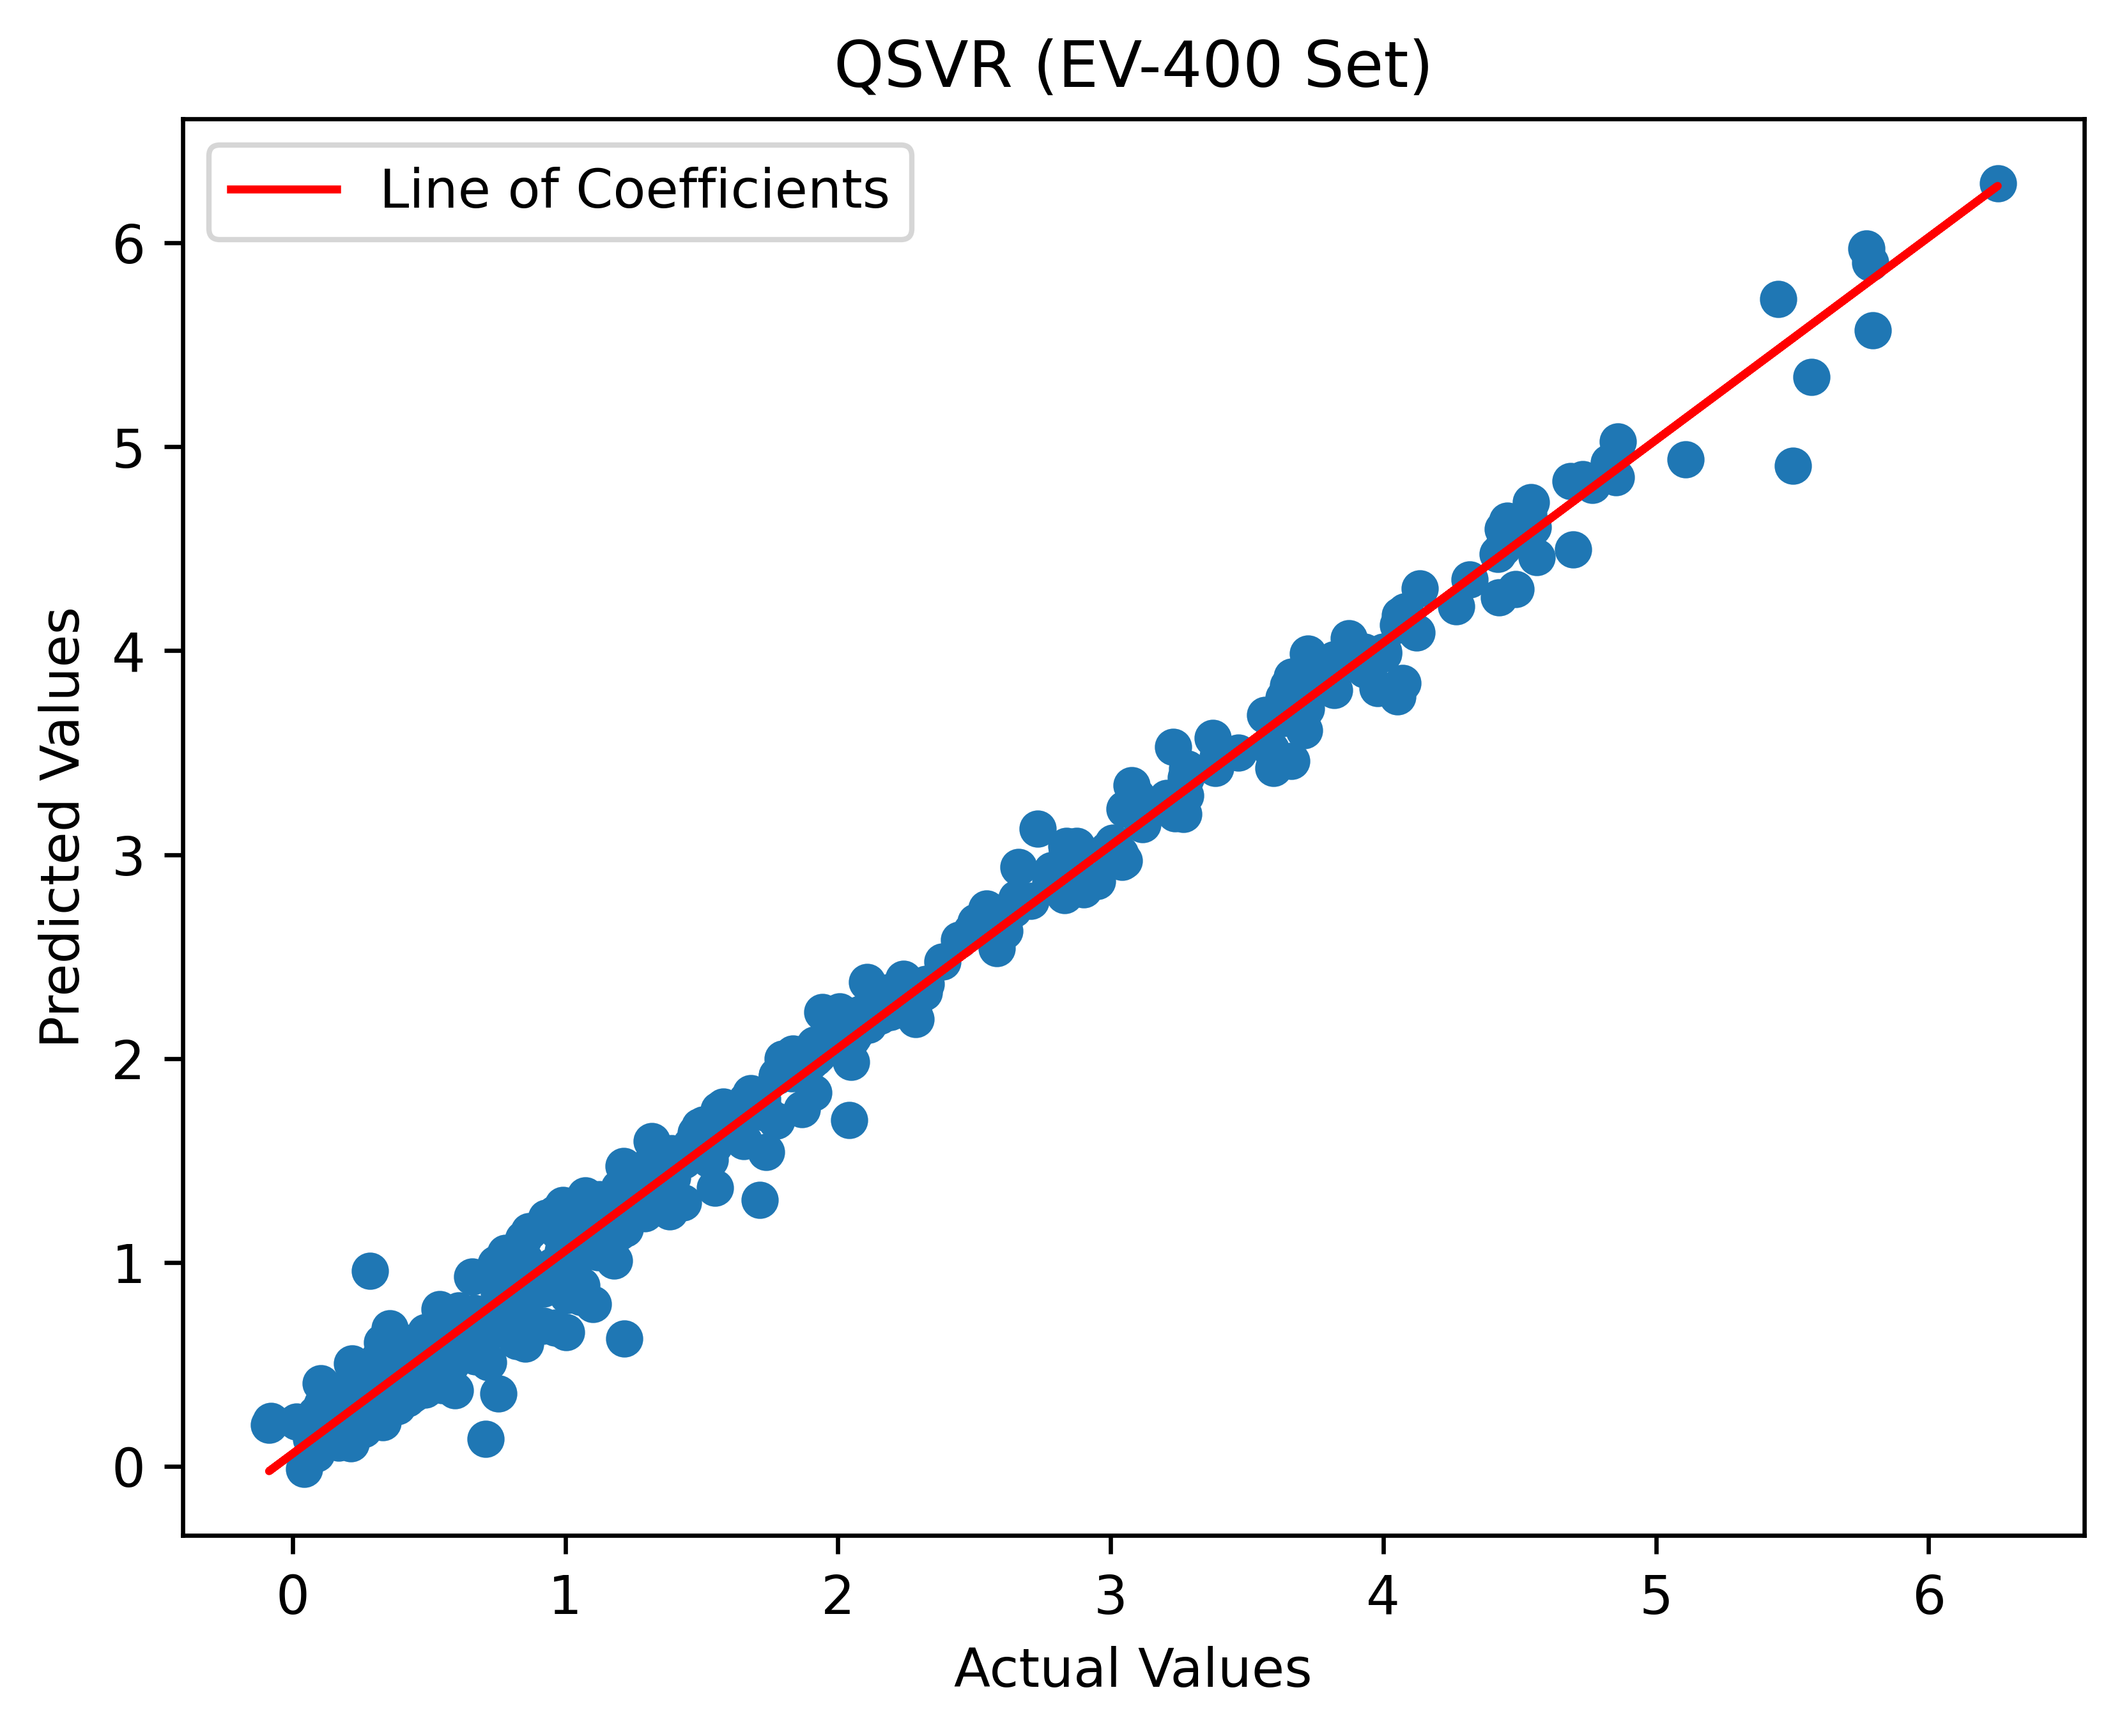

In [24]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("QSVR (EV-400 Set)")#title
plt.legend()

In [25]:
df6=pd.read_csv('C:/Users/NIT/Desktop/PAPER FINALIZED WORK BAND 2D DT-25-02-2025/other qubit variation using optimized hyp/study-fm-pro/uncetainity and valida/external dataset/750 clean data repeat .csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y6 = df6['Band gap ']

# defining target
x6=df6[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test6=  scaler.transform(x6)

# Compute the test kernel matrix (train-test kernel)
K_test6 = np.zeros((len(x_test6), len(X_train_scaled)))
for i in range(len(x_test6)):
    for j in range(len(X_train_scaled)):
        K_test6[i, j] = quantum_kernel(x_test6[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred6 = svr.predict(K_test6)
print("Predicted values:", y_pred6)

Predicted values: [ 4.22218037  0.20212667  0.75146878  0.91042587  1.80092074  1.17579184
  4.07355874  0.5629622   3.12848717  1.68280717  3.08130473  0.44746423
  2.9437204   0.64880107  3.16000649  0.15180717  0.70358255  3.69516222
  1.60871667  0.76692537  3.60092508  0.87911607  1.51710656  0.30636233
  1.92502425  1.52593103  0.6358012   0.94702875  0.58292992  1.1021043
  3.56925552  2.17655226  1.28088354  4.03215336  0.58147591  0.81830834
  2.53194312  2.04531774  1.02984533  0.18207403  1.12190713  1.3399562
  0.65456107  1.39352095  3.68335323  1.23047057  0.61115291  2.21629699
  3.09531643  1.05952043  1.89844376  1.88212216  2.05179351  1.53865171
  0.80351069  2.53351082  2.33613149  1.40625867  4.51607108  1.81730463
  4.06069031  1.84880472  1.19848743  1.60033492  4.49339558  1.10197772
  1.54249223  1.0254417   0.53775983  0.47053875  1.50703474  1.35946982
  2.27792687  0.60495162  0.39613448  1.58544424  3.18528018  2.05151552
  1.43145756  2.61813137  0.4275683

In [31]:
import numpy as np
from scipy.stats import shapiro

errors_750 = np.asarray(y6) - np.asarray(y_pred6)

W, p_value = shapiro(errors_750)

print("Shapiro-Wilk W-dataset-750 =", W)
print("p-value-dataset-750 =", p_value)

Shapiro-Wilk W-dataset-750 = 0.967036244597377
p-value-dataset-750 = 5.8145822604720865e-12


Model evaluation - Test Set:
r^2: 0.9876538417243188
MAE 0.11873630192295456
RMSE: 0.149652288709542


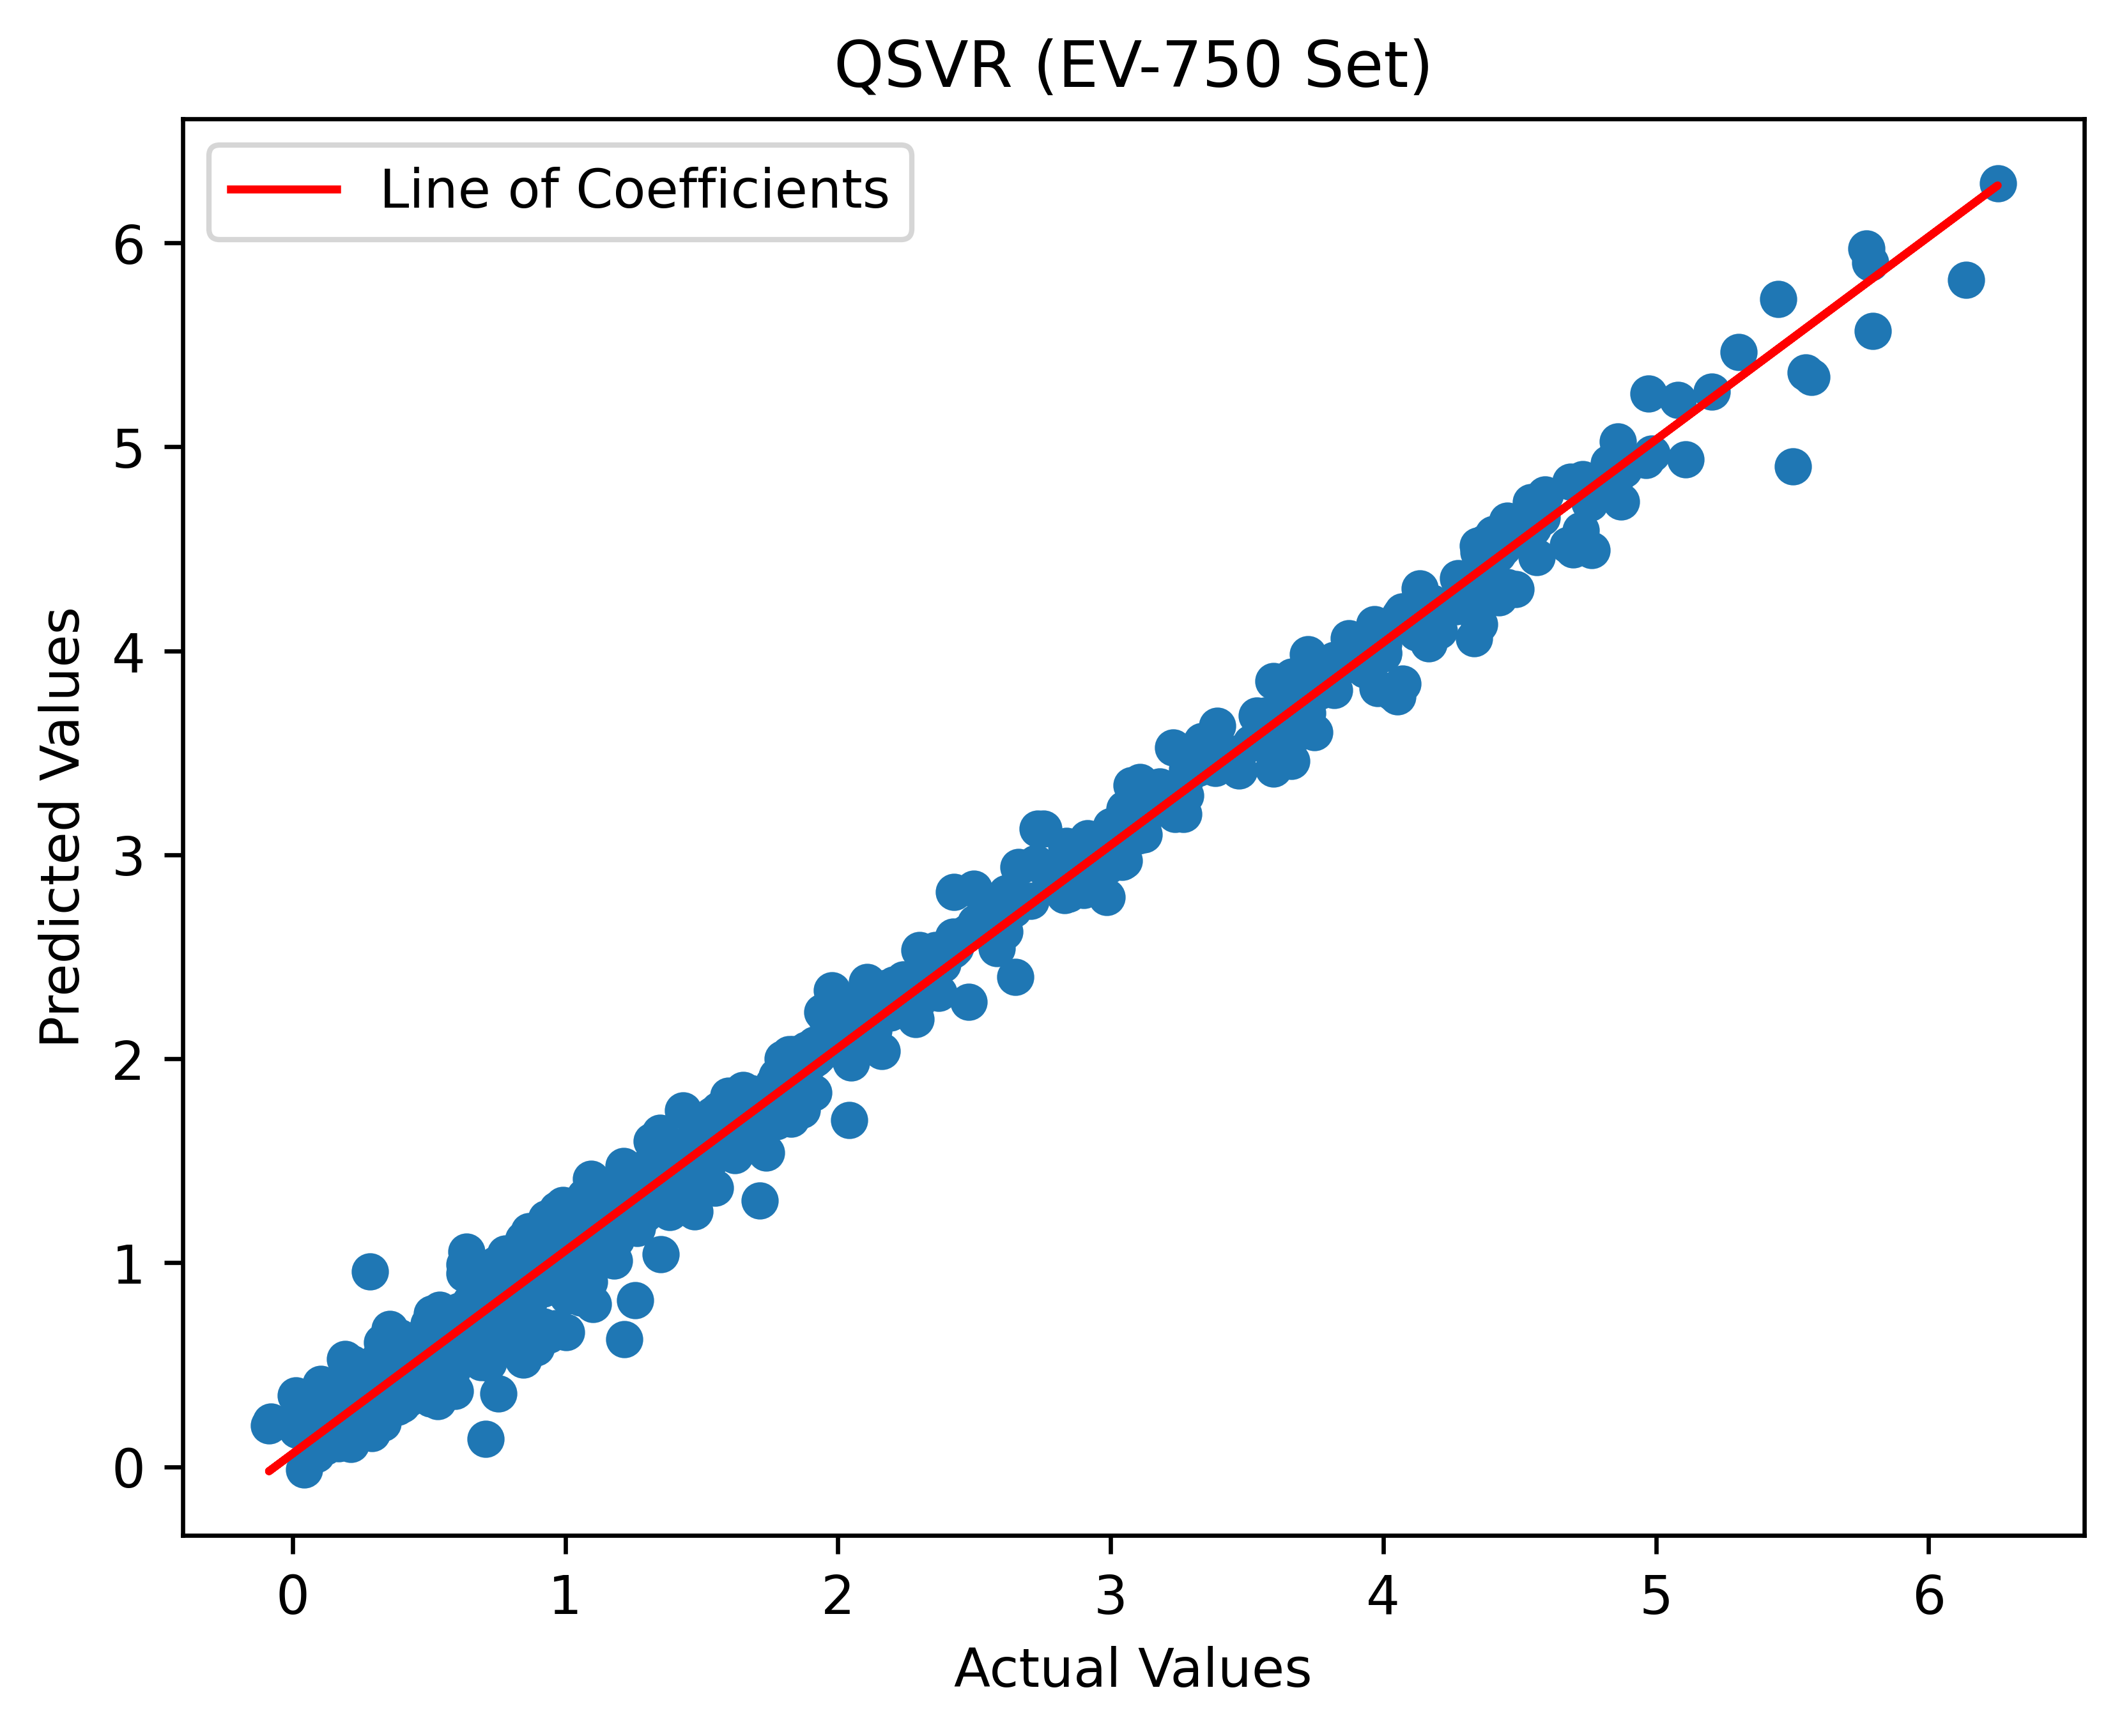

In [26]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y6, y_pred6))
print('MAE', mean_absolute_error(y6, y_pred6))
print('RMSE:',np.sqrt(mean_squared_error(y6, y_pred6)))
# Plot straight line
plt.figure(dpi=600)
plt.scatter(y6, y_pred6)
coefficients = np.polyfit(y6, y_pred6, 1)
line = np.polyval(coefficients, y6)
plt.plot(y6, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y6, y_pred6)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y6, y_pred6))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y6, y_pred6)), (-0.2, 13.2))
plt.title("QSVR (EV-750 Set)")#title
plt.legend()

In [27]:
import numpy as np

K = np.asarray(K_train)
y = np.asarray(y_train)

# Centering matrix
n = len(y)
H = np.eye(n) - np.ones((n, n)) / n

# Center quantum kernel
Kc = H @ K @ H

# Target kernel
Ky = np.outer(y, y)

# Center target kernel
Kyc = H @ Ky @ H

# Kernel-target alignment
alignment = np.sum(Kc * Kyc) / np.sqrt(
    np.sum(Kc**2) * np.sum(Kyc**2)
)

print("Kernel-target alignment =", alignment)

Kernel-target alignment = 0.2323820273681226
